import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\hp\Documents\Data_science\DATA_SCIENCE_first\INOHA-DataScience-M2\donnees_mpox_RDC_3000.csv")
df

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


In [4]:
df.columns

Index(['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             3000 non-null   int64  
 14  Saison  

In [21]:
print("\n" + "="*70)
print("ANALYSE EXPLORATOIRE APPROFONDIE (EDA)")
print("="*70)

# --- 1. STATISTIQUES DESCRIPTIVES DÉTAILLÉES ---
print("\n Statistiques descriptives des variables numériques :")
print(df[['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct']].describe())


ANALYSE EXPLORATOIRE APPROFONDIE (EDA)

 Statistiques descriptives des variables numériques :
           Semaine  Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count  3000.000000      3000.000000    3000.000000  3000.000000   3000.000000   
mean   1500.500000       157.779667      24.980367     0.451182     71.571667   
std     866.169729       101.958774       3.832510     0.157799     11.625285   
min       1.000000         2.000000      18.000000     0.103000     40.000000   
25%     750.750000        77.000000      22.300000     0.331000     64.000000   
50%    1500.500000       136.000000      24.900000     0.452000     71.500000   
75%    2250.250000       221.000000      27.600000     0.576000     80.000000   
max    3000.000000       400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333        

La moyenne (79,6) est supérieure à la médiane (57), ce qui suggère une asymétrie à droite : quelques observations présentent un nombre de cas très élevé.
L'écart-type (70,1) est élevé, indiquant une forte variabilité du nombre de cas entre les observations.
La présence de valeurs allant jusqu'à 479 cas laisse penser qu'il existe des semaines ou provinces avec des flambées importantes.

Pluviométrie
moyenne : 157,8 mm
min : 2 mm
max : 400 mm
Les précipitations varient fortement, ce qui peut influencer la transmission de certaines maladies.
Température
moyenne : 24,98°C
min : 18°C
max : 34°C
La température est relativement stable, normal un contexte contexte tropical comme la RDC.
NDVI
moyenne : 0,45
min : 0,103
max : 0,795
Le NDVI présente une bonne variabilité, représentant des environnements allant de peu végétalisés à fortement végétalisés.

Humidité
moyenne : 71,6 %
comprise entre 40 % et 95 %
Normale pour un climat tropical humide.

Densité de population
moyenne : 119 habitants/km²
maximum : 500 habitants/km²
y'a des zones fortement peuplés par rapport a d'autre 

Couverture vaccinale
moyenne : 31,8 %
minimum : 5,6 %
maximum : 77,8 %
On observe une importante hétérogénéité de la couverture vaccinale.

Tests réalisés
moyenne : 286 tests
maximum : 800 tests
Le nombre de tests varie considérablement d'une observation à l'autre.

Taux de positivité
moyenne : 27 %
maximum : 95 %
ce résultat traduit des épisodes épidémiques ou une stratégie de dépistage ciblée. d'ou nous devons le déterminer

Distance au centre de santé
moyenne : 15,6 km
maximum : 142 km
Certaines populations vivent très loin des structures de santé, ce qui peut influencer la détection et la prise en charge des cas.

Réservoirs animaux
La moyenne (0,40) indique qu'environ 40 % des observations présentent des réservoirs animaux.

Les statistiques descriptives montrent que le jeu de données est de bonne qualité, sans valeurs manquantes et avec des variables présentant une variabilité suffisante pour la modélisation. La variable cible (Cas_Confirmes) est asymétrique à droite, avec quelques valeurs élevées correspondant probablement à des flambées épidémiques. Les variables climatiques, démographiques et sanitaires présentent des amplitudes importantes, suggérant qu'elles pourraient contribuer à expliquer la variation du nombre de cas confirmés de Mpox.

In [8]:
# --- 2. VÉRIFICATION DES VALEURS MANQUANTES ---
print("\n Vérification des valeurs manquantes :")
print(df.isnull().sum())


 Vérification des valeurs manquantes :
ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns = ['Saison']
for i in columns :
  df[i] = le.fit_transform(df[i])
df

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,0,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,1,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,1,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,0,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,0,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,0,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,1,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,0,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,0,4813,43.24


In [23]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'Pluie': np.int64(0), 'Seche': np.int64(1)}


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   object 
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine          3000 non-null   int64  
 13  Cas_Confirmes             3000 non-null   int64  
 14  Saison  

In [13]:
# --- 3. MATRICE DE CORRÉLATION ---
print("\n Matrice de corrélation :")
corr_matrix = df[['Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct']].corr()
print(corr_matrix.round(4))


 Matrice de corrélation :
                          Semaine  Pluviometrie_mm  Temperature_C    NDVI  \
Semaine                    1.0000           0.0217        -0.0031 -0.0083   
Pluviometrie_mm            0.0217           1.0000         0.0266 -0.0253   
Temperature_C             -0.0031           0.0266         1.0000  0.0108   
NDVI                      -0.0083          -0.0253         0.0108  1.0000   
Humidite_pct              -0.0044          -0.0178         0.0134 -0.0141   
Densite_Population        -0.0247           0.0150        -0.0157 -0.0135   
Couverture_Vaccinale_pct  -0.0063          -0.0124         0.0116  0.0313   
Tests_Realises             0.0087           0.0017        -0.0305 -0.0416   
Distance_Centre_Sante_km  -0.0200           0.0340         0.0077 -0.0261   
Reservoirs_Animaux         0.0111          -0.0233         0.0078 -0.0118   
Mobilite_Humaine          -0.0236           0.0100         0.0057  0.0259   
Cas_Confirmes              0.0079           0.625

Taux de positivité (r = 0,8999) : C'est la variable la plus liée au nombre de cas confirmés, Plus le taux de positivité augmente, plus le nombre de cas confirmés augmente également.

L'analyse de corrélation montre que le taux de positivité (a exclure), la pluviométrie et le nombre de tests réalisés sont les variables les plus fortement associées au nombre de cas confirmés de Mpox. À l'inverse, la couverture vaccinale et la saison présentent des corrélations négatives modérées, c'est à dire une  meilleure couverture vaccinale ou certaines périodes de l'année sont associées à une diminution des cas. Les autres variables présentent des corrélations faibles.

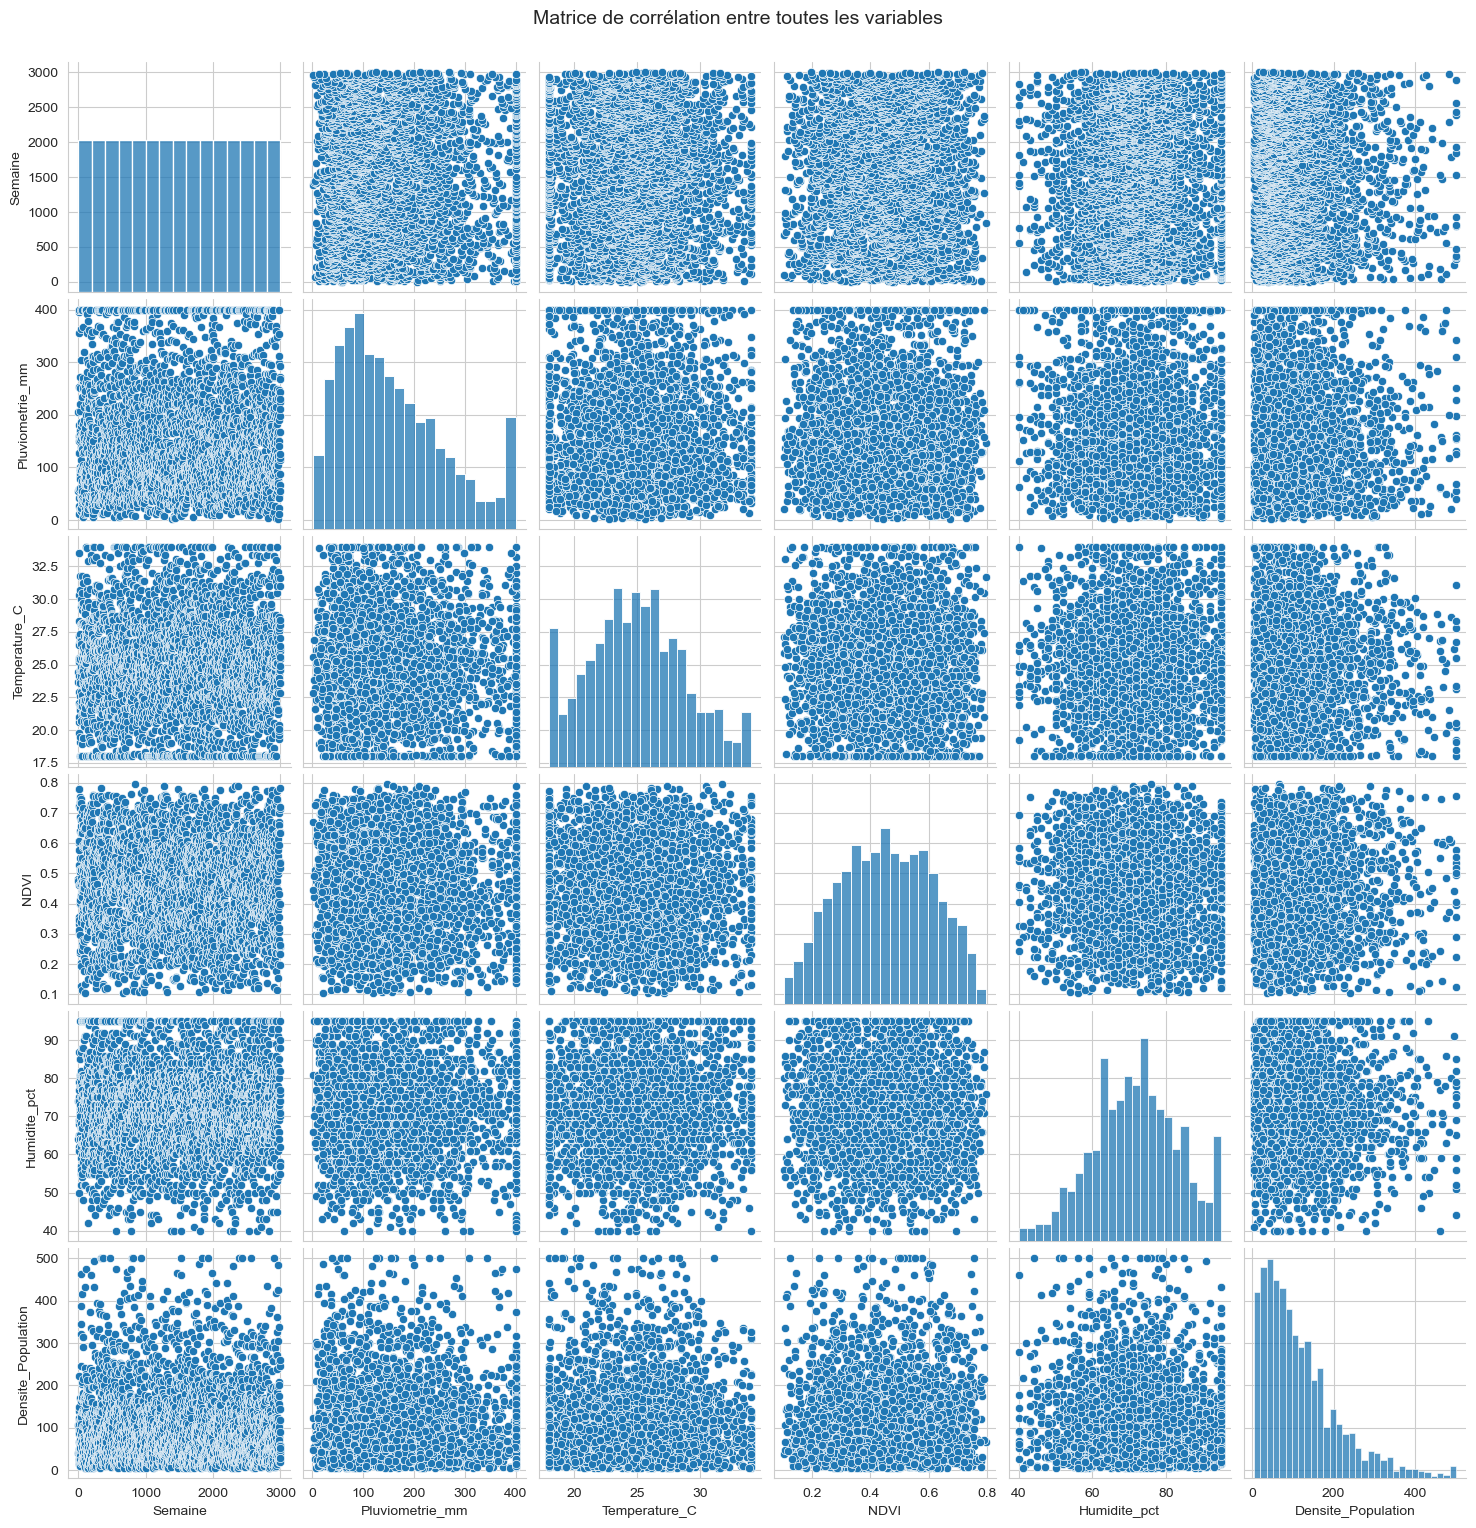

In [15]:
# --- 4. VISUALISATIONS ---

# 4.1. Pairplot (matrice de corrélation visuelle)
sns.set_style("whitegrid")
pairplot = sns.pairplot(df[['Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population']])
pairplot.fig.suptitle("Matrice de corrélation entre toutes les variables", y=1.02, fontsize=14)
plt.show()

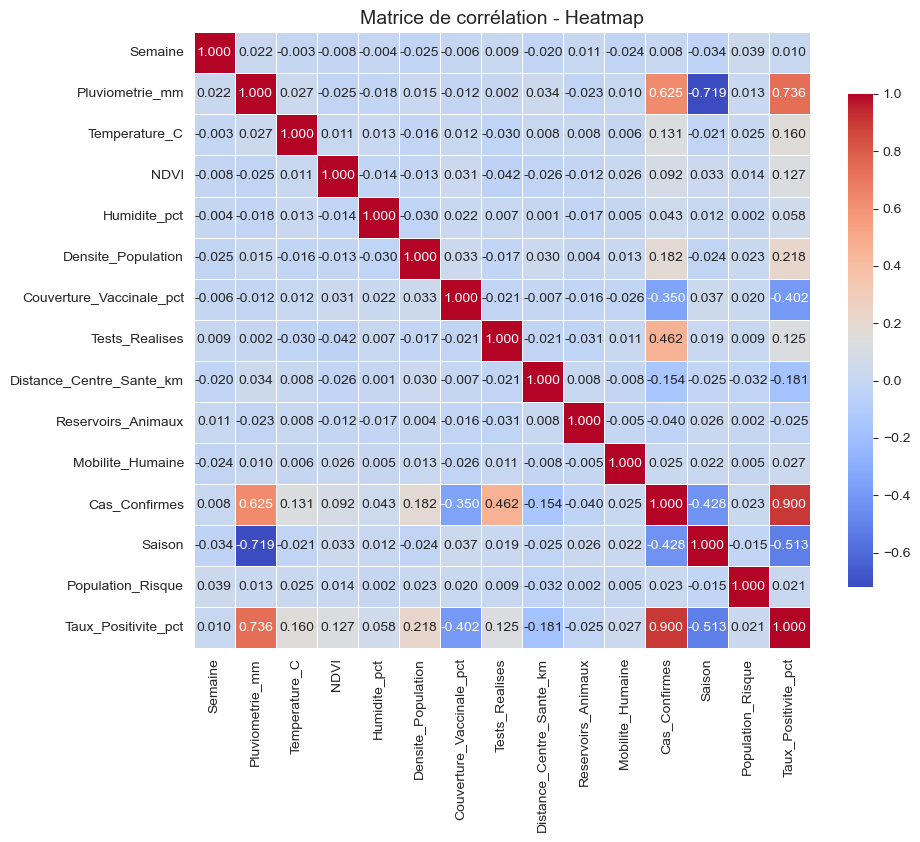

In [16]:
# 4.2. Heatmap de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation - Heatmap", fontsize=14)
plt.show()

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = df[[
    "Semaine",
    "Pluviometrie_mm",
    "Temperature_C",
    "NDVI",
    "Humidite_pct",
    "Densite_Population",
    "Couverture_Vaccinale_pct",
    "Tests_Realises",
    "Distance_Centre_Sante_km",
    "Reservoirs_Animaux",
    "Mobilite_Humaine",
    "Saison",
    "Population_Risque"
]]
X_const = add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

                    Variable         VIF
0                      const  130.235761
12                    Saison    2.082850
2            Pluviometrie_mm    2.077131
7   Couverture_Vaccinale_pct    1.006651
4                       NDVI    1.006064
8             Tests_Realises    1.006055
6         Densite_Population    1.005796
9   Distance_Centre_Sante_km    1.004751
13         Population_Risque    1.004657
1                    Semaine    1.004591
11          Mobilite_Humaine    1.004321
3              Temperature_C    1.003157
10        Reservoirs_Animaux    1.002793
5               Humidite_pct    1.002531


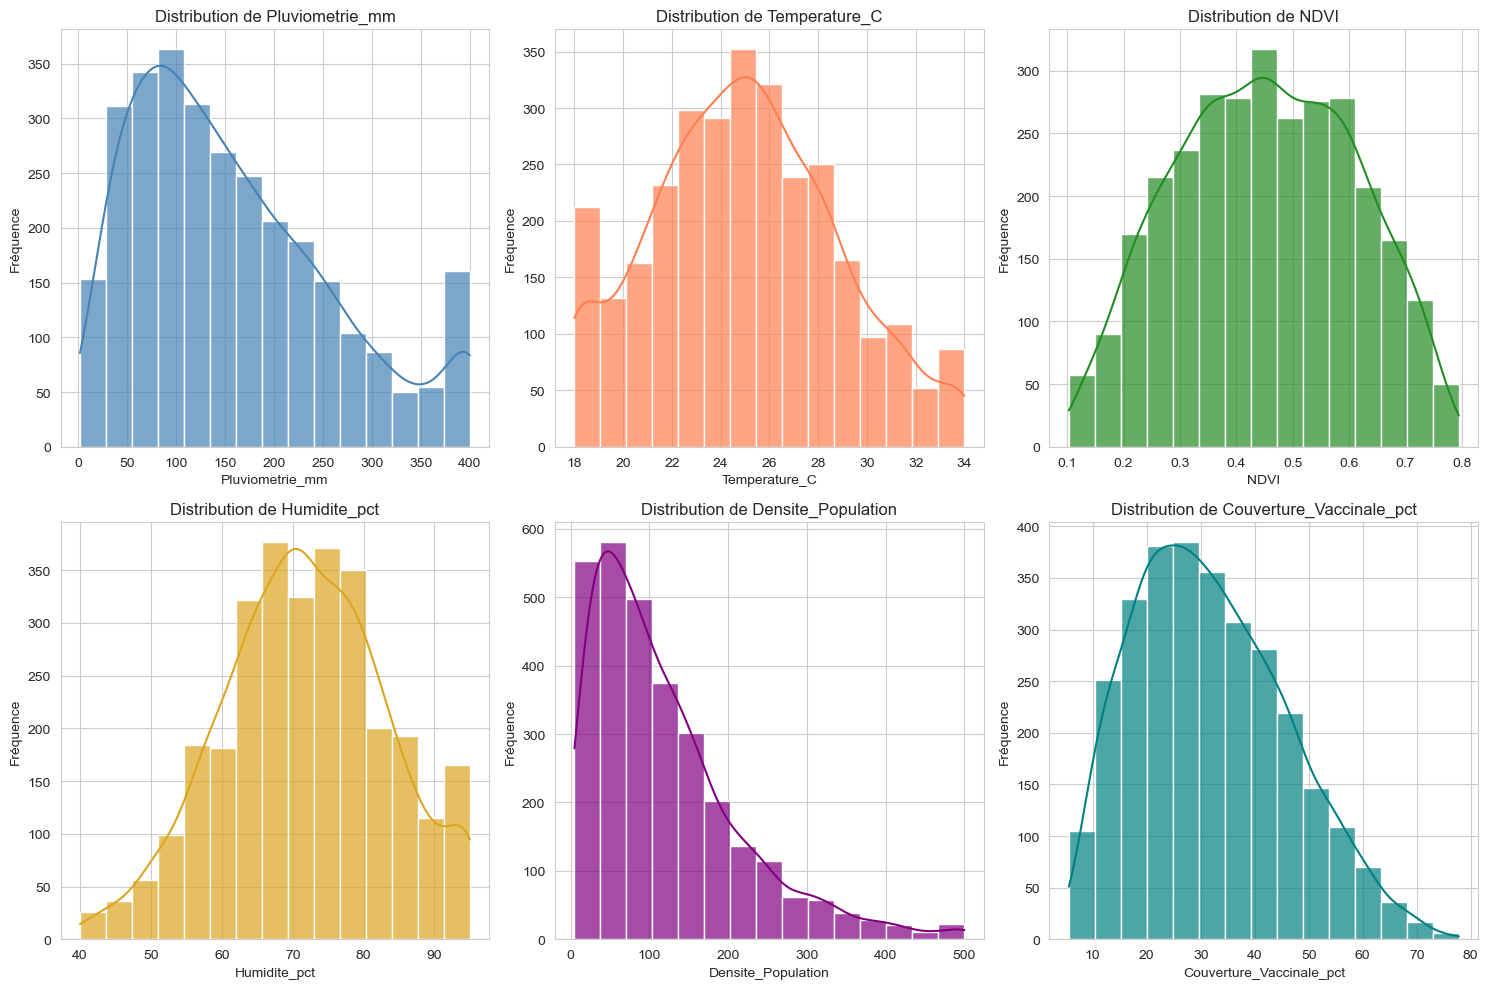

In [27]:
# 4.3. Distribution des variables (Histogrammes + KDE)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

variables = ['Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct']
couleurs = ['steelblue', 'coral', 'forestgreen', 'goldenrod', 'purple', 'teal']

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.histplot(df[var], kde=True, ax=axes[i], color=color, bins=15, alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

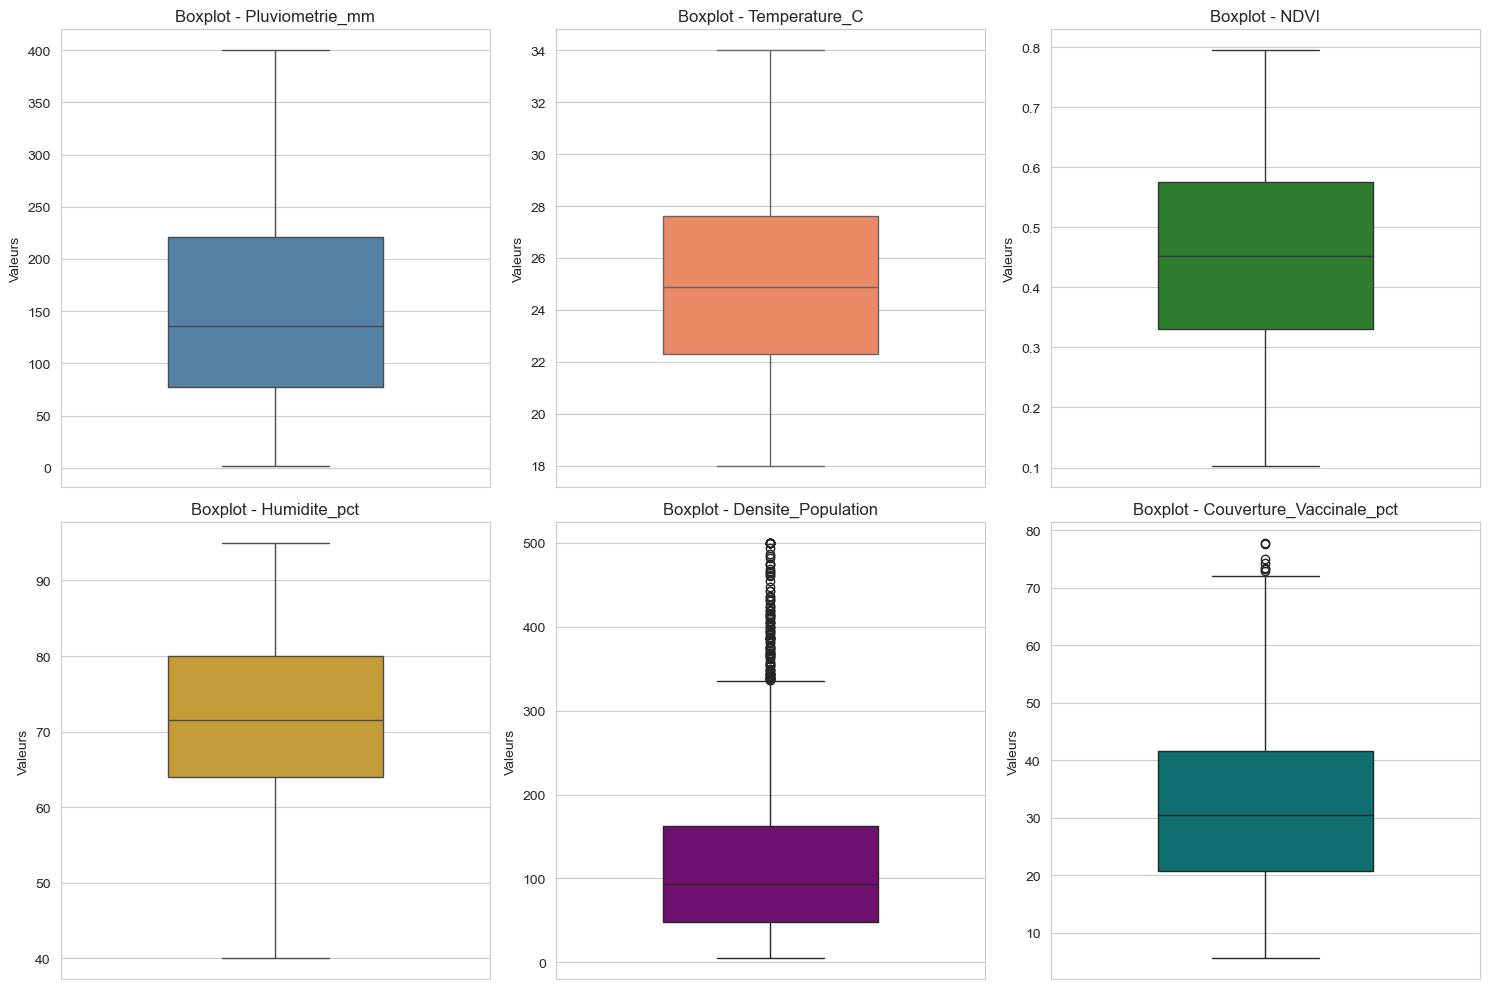

In [28]:
# 4.4. Boxplots pour détecter les outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.boxplot(y=df[var], ax=axes[i], color=color, width=0.5)
    axes[i].set_title(f'Boxplot - {var}')
    axes[i].set_ylabel('Valeurs')

plt.tight_layout()
plt.show()

In [35]:
X = df.drop(
    columns=[
        "ID",
        "Cas_Confirmes",
        "Taux_Positivite_pct"
    ]
)

y = df["Cas_Confirmes"]

In [ ]:
#One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=["Province"],
    drop_first=True
)

In [40]:
X.head()

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,...,Province_Mongala,Province_Nord-Kivu,Province_Nord-Ubangi,Province_Sankuru,Province_Sud-Kivu,Province_Sud-Ubangi,Province_Tanganyika,Province_Tshopo,Province_Tshuapa,Province_Équateur
0,1,206,24.4,0.480,64,39,31.8,150,22,1,...,True,False,False,False,False,False,False,False,False,False
1,2,56,23.7,0.474,74,107,24.9,300,5,1,...,False,False,False,False,False,False,False,False,False,False
2,3,59,25.2,0.333,62,140,53.9,310,16,0,...,False,False,False,False,False,False,False,False,False,False
3,4,396,24.1,0.354,68,97,25.9,210,4,0,...,False,False,False,False,False,False,False,False,False,False
4,5,127,19.8,0.303,61,86,30.3,260,24,1,...,False,False,False,False,False,False,False,False,False,False


In [41]:
print(X.shape)

(3000, 38)


In [42]:
print(X.columns.tolist())

['Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Saison', 'Population_Risque', 'Province_Haut-Katanga', 'Province_Haut-Lomami', 'Province_Haut-Uele', 'Province_Ituri', 'Province_Kasaï', 'Province_Kasaï-Central', 'Province_Kasaï-Oriental', 'Province_Kinshasa', 'Province_Kongo Central', 'Province_Kwango', 'Province_Kwilu', 'Province_Lomami', 'Province_Lualaba', 'Province_Mai-Ndombe', 'Province_Maniema', 'Province_Mongala', 'Province_Nord-Kivu', 'Province_Nord-Ubangi', 'Province_Sankuru', 'Province_Sud-Kivu', 'Province_Sud-Ubangi', 'Province_Tanganyika', 'Province_Tshopo', 'Province_Tshuapa', 'Province_Équateur']


In [44]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Semaine                   3000 non-null   int64  
 1   Pluviometrie_mm           3000 non-null   int64  
 2   Temperature_C             3000 non-null   float64
 3   NDVI                      3000 non-null   float64
 4   Humidite_pct              3000 non-null   int64  
 5   Densite_Population        3000 non-null   int64  
 6   Couverture_Vaccinale_pct  3000 non-null   float64
 7   Tests_Realises            3000 non-null   int64  
 8   Distance_Centre_Sante_km  3000 non-null   int64  
 9   Reservoirs_Animaux        3000 non-null   int64  
 10  Mobilite_Humaine          3000 non-null   int64  
 11  Saison                    3000 non-null   int64  
 12  Population_Risque         3000 non-null   int64  
 13  Province_Haut-Katanga     3000 non-null   bool   
 14  Province

In [47]:
X = X.astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Semaine                   3000 non-null   int64
 1   Pluviometrie_mm           3000 non-null   int64
 2   Temperature_C             3000 non-null   int64
 3   NDVI                      3000 non-null   int64
 4   Humidite_pct              3000 non-null   int64
 5   Densite_Population        3000 non-null   int64
 6   Couverture_Vaccinale_pct  3000 non-null   int64
 7   Tests_Realises            3000 non-null   int64
 8   Distance_Centre_Sante_km  3000 non-null   int64
 9   Reservoirs_Animaux        3000 non-null   int64
 10  Mobilite_Humaine          3000 non-null   int64
 11  Saison                    3000 non-null   int64
 12  Population_Risque         3000 non-null   int64
 13  Province_Haut-Katanga     3000 non-null   int64
 14  Province_Haut-Lomami      3000 non-null 

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Standardisation
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)
# Normalisation Min-Max
scaler_minmax = MinMaxScaler()
X_train_mm = scaler_minmax.fit_transform(X_train)
X_test_mm = scaler_minmax.transform(X_test)

In [51]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
models = {
    "Linear Regression": LinearRegression(),
    
    "Ridge": Ridge(alpha=1.0),
    
    "Lasso": Lasso(alpha=0.1),
    
    "ElasticNet": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5
    )
}

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


def evaluate_model(model, X_train, X_test):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )
    
    r2 = r2_score(y_test, y_pred)
    
    return mae, rmse, r2

In [53]:
results = []

for scaler_name, Xtr, Xte in [
    ("StandardScaler", X_train_std, X_test_std),
    ("MinMaxScaler", X_train_mm, X_test_mm)
]:
    
    for model_name, model in models.items():
        
        mae, rmse, r2 = evaluate_model(
            model,
            Xtr,
            Xte
        )
        
        results.append([
            scaler_name,
            model_name,
            mae,
            rmse,
            r2
        ])

In [54]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Scaler",
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Scaler,Model,MAE,RMSE,R2
6,MinMaxScaler,Lasso,22.841446,31.935804,0.809589
2,StandardScaler,Lasso,22.989330,31.942115,0.809514
0,StandardScaler,Linear Regression,23.051800,31.967101,0.809216
4,MinMaxScaler,Linear Regression,23.051800,31.967101,0.809216
1,StandardScaler,Ridge,23.048030,31.968674,0.809197
5,MinMaxScaler,Ridge,22.963500,32.024842,0.808526
3,StandardScaler,ElasticNet,22.849985,32.375981,0.804304
7,MinMaxScaler,ElasticNet,34.217920,49.629087,0.540158


In [59]:
# Colonnes provinces
province_cols = [col for col in X.columns if col.startswith("Province_")]
# X sans provinces
X_no_province = X.drop(columns=province_cols)
print(X_no_province.shape)
print(X_no_province.columns.tolist())

(3000, 13)
['Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Saison', 'Population_Risque']


In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_no_province,y,test_size=0.2,random_state=42)

In [61]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

In [62]:
from sklearn.linear_model import RidgeCV
alphas = [0.001,0.01,0.1,1,10,100,1000]
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5
)
ridge_cv.fit(
    X_train_std,
    y_train
)
print("Meilleur alpha Ridge :", ridge_cv.alpha_)

Meilleur alpha Ridge : 10.0


In [63]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(
    alphas=None,
    cv=5,
    max_iter=10000
)
lasso_cv.fit(
    X_train_std,
    y_train
)
print("Meilleur alpha Lasso :", lasso_cv.alpha_)

Meilleur alpha Lasso : 0.043425111188597355


In [64]:
from sklearn.linear_model import ElasticNetCV

elastic_cv = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9],
    cv=5,
    max_iter=10000
)
elastic_cv.fit(
    X_train_std,
    y_train
)
print("Meilleur alpha ElasticNet :", elastic_cv.alpha_)
print("Meilleur l1_ratio :", elastic_cv.l1_ratio_)

Meilleur alpha ElasticNet : 0.04825012354288595
Meilleur l1_ratio : 0.9


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


def metrics(model, X_test):
    
    y_pred = model.predict(X_test)
    
    MAE = mean_absolute_error(y_test,y_pred)
    
    RMSE = np.sqrt(
        mean_squared_error(y_test,y_pred)
    )
    
    R2 = r2_score(y_test,y_pred)
    
    return MAE, RMSE, R2

In [66]:
results = []
models = {
    "Ridge": ridge_cv,
    "Lasso": lasso_cv,
    "ElasticNet": elastic_cv
}
for name, model in models.items():
    
    mae, rmse, r2 = metrics(
        model,
        X_test_std
    )
    
    results.append(
        [name, mae, rmse, r2]
    )

pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

,Model,MAE,RMSE,R2
0,Ridge,22.973843,31.883894,0.810207
1,Lasso,22.987548,31.864386,0.810440
2,ElasticNet,22.946419,31.885082,0.810193


In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entraînement
linear_model = LinearRegression()
linear_model.fit(
    X_train_std,
    y_train
)
# Prédiction
y_pred_linear = linear_model.predict(X_test_std)

# Métriques
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)
r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("MAE :", mae_linear)
print("RMSE :", rmse_linear)
print("R² :", r2_linear)

MAE : 23.01237640428331
RMSE : 31.868029855604597
R² : 0.8103962764846628


In [68]:
coef_linear = pd.DataFrame({
    "Variable": X_no_province.columns,
    "Coefficient": linear_model.coef_
})
coef_linear.sort_values(
    by="Coefficient",
    ascending=False
)

,Variable,Coefficient
1,Pluviometrie_mm,4.621163e+01
7,Tests_Realises,3.116712e+01
5,Densite_Population,1.355303e+01
2,Temperature_C,9.970249e+00
4,Humidite_pct,4.277777e+00
11,Saison,3.910737e+00
12,Population_Risque,5.444471e-01
10,Mobilite_Humaine,5.064943e-02
3,NDVI,-3.552714e-15
0,Semaine,-8.082466e-01


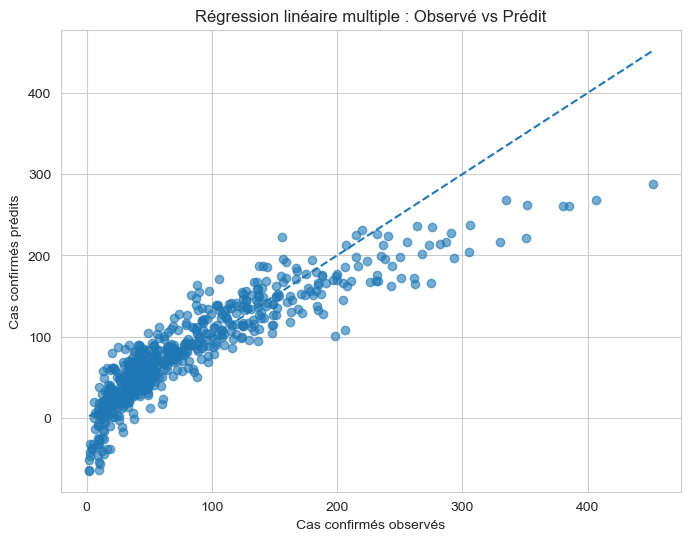

In [69]:
import matplotlib.pyplot as plt
import numpy as np
# Prédictions
y_pred = linear_model.predict(X_test_std)
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)
# Ligne parfaite
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Cas confirmés observés")
plt.ylabel("Cas confirmés prédits")
plt.title("Régression linéaire multiple : Observé vs Prédit")
plt.show()

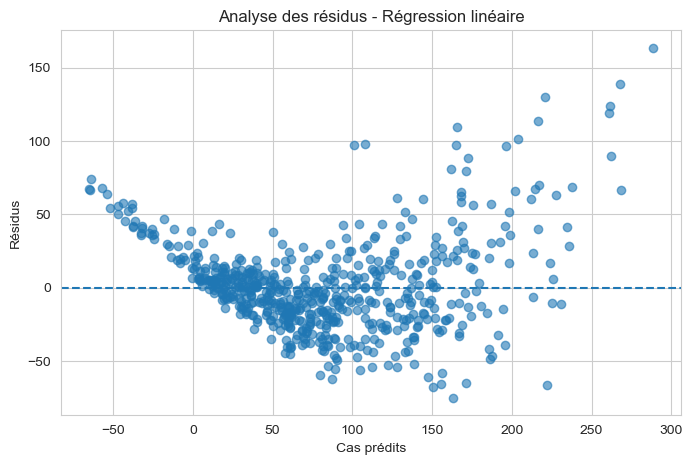

In [70]:
residus = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(
    y_pred,
    residus,
    alpha=0.6
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Cas prédits")
plt.ylabel("Résidus")
plt.title("Analyse des résidus - Régression linéaire")
plt.show()

les épidémies ne dependent de mpox ne dependent pas forcement de : pluie ;température ;vaccination ;tests.
et dans notre dataset il manque probablement : délai de notification ; contacts ; mouvements transfrontaliers ; interventions de santé publique ; structure du réseau social.

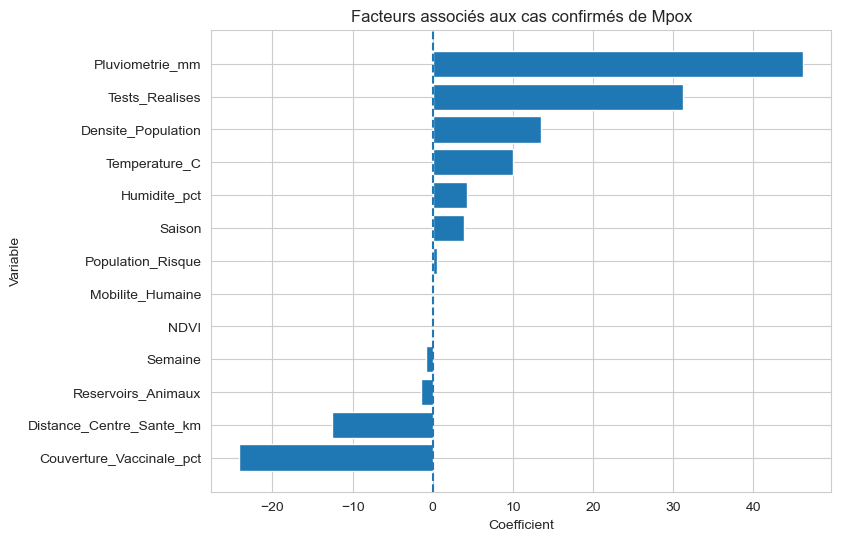

In [71]:
coef_df = pd.DataFrame({
    "Variable": X_no_province.columns,
    "Coefficient": linear_model.coef_
})
coef_df = coef_df.sort_values(
    by="Coefficient"
)
plt.figure(figsize=(8,6))
plt.barh(
    coef_df["Variable"],
    coef_df["Coefficient"]
)
plt.axvline(
    x=0,
    linestyle="--"
)
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Facteurs associés aux cas confirmés de Mpox")
plt.show()

Le modèle de régression linéaire multiple présente une performance satisfaisante (R² = 0,81), indiquant que le modèle explique environ 81 % de la variabilité des cas confirmés. L’erreur moyenne absolue (MAE = 23 cas) signifie que les prédictions s’écartent en moyenne d’environ 23 cas des valeurs observées, tandis que le RMSE = 31,9 cas, légèrement supérieur au MAE, suggère l’existence de quelques épisodes pics épidémiques. L’analyse des coefficients met en évidence la contribution positive de la pluviométrie, des tests réalisés et de la densité de population, tandis que la couverture vaccinale et l’accessibilité aux soins sont associées à une diminution des cas observés. Ces résultats montrent que le modèle est utile comme outil d’aide à la décision pour identifier les périodes et zones nécessitant un renforcement de la surveillance.